# Dataset statistics

Reproduces the **dataset-statistics** figure theme of the DeepCell Types paper:
the cell-type / tissue / modality composition of the expanded-TissueNet
archive, the channel (marker) panel landscape, and the marker-discriminability
diagnostics.

Panels, in order:

- **Cell-type abundance — Supp. Fig. 2**
- **Composition by modality / tissue / lineage — Fig. 1b**
- **Cell-type presence per dataset — Supp. Fig. 1a**
- **Cell-type lineage hierarchy — Fig. 1d**
- **Per-dataset cell-count distribution — Supp. Fig. 1c**
- **Class-imbalance curve — Supp. Fig. 1d**
- **Cell-type breakdown per modality — Fig. 1c**
- **Channel co-occurrence (Jaccard) — Supp. Fig. 1b**
- **Per-channel panel statistics (incl. markers-per-FOV) — Supp. Fig. 1e**
- **Single-channel marker discriminability (mutual information) — Supp. Fig. 3**

> **Provenance / execution note.** Most panels are computed live from the
> **expanded-TissueNet zarr archive** (`paths.EXPANDED_TISSUENET_ZARR`; public
> users set `DATA_DIR` to their downloaded copy). The per-cell metadata scan
> walks one `zarr.json` triple per FOV across the split's ~2.1k FOVs, so the
> shared-scan cell below is **slow** (a few minutes). The marker-discriminability
> mutual-information panel reads the cached per-cell intensity table
> (`channel_intensity_stats.npz`) so it needs no archive rescan. The per-cell
> scan uses the `splits/fov_split_valsubset.json` split (train + val +
> held-out).

All figures use a consistent publication figure style via `dct_figures.style`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from dct_figures import paths, style, colors
style.apply_style()

In [2]:
import json, yaml
from collections import Counter, defaultdict
from pathlib import Path
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

from dct_figures.style import (
    PAL, LINEAGE_COLORS, LINEAGE_ORDER, STACKED_COLORS,
    CMAP_BLUES, CMAP_WARM, COL_1, COL_1_5, COL_2, MAX_HEIGHT,
    BAR_WIDTH, style_ax, use_log_count_axis,
)

## Shared archive scan (per-FOV metadata)

Walks the zarr archive's per-FOV metadata once (tissue, modality, channel
panel, per-cell-type counts) and reuses it across the panels below. The scan is
computed **once** here and reused across every downstream panel (DRY).

In [3]:
import zarr

SPLIT_FILE = paths.SPLITS / 'fov_split_valsubset.json'
ZARR_PATH = paths.need(paths.EXPANDED_TISSUENET_ZARR)


class ArchiveConfig:
    '''Config object built from the expanded-TissueNet zarr archive.

    Provides only the fields the data-stats plotting code reads,
    derived directly from the archive root attrs and the
    per-FOV zarr.json files.
    '''

    def __init__(self, zarr_path):
        self.zarr_path = pathlib.Path(zarr_path)
        self._zf = zarr.open_group(str(self.zarr_path), mode='r')
        attrs = dict(self._zf.attrs)
        # ct2idx from the archive cell_type_mapping (51 standardized types).
        self.ct2idx = {ct: idx for ct, idx in attrs.get('cell_type_mapping', {}).items()}
        self.lineage_mapping = dict(attrs.get('lineage_mapping', {}))
        self.color_mapping = dict(attrs.get('color_mapping', {}))
        self._dataset_keys = None
        self._tissue_ct = None
        self._mp_cache = {}

    @property
    def dataset_keys(self):
        if self._dataset_keys is None:
            root = str(self.zarr_path)
            self._dataset_keys = sorted(
                p.parent.parent.relative_to(root).as_posix()
                for p in self.zarr_path.glob('**/preprocessed/zarr.json')
            )
        return self._dataset_keys

    @property
    def tissue_celltype_mapping(self):
        '''tissue -> sorted list of annotated cell types (in ct2idx).'''
        if self._tissue_ct is None:
            tmap = defaultdict(set)
            zdir = str(self.zarr_path)
            for key in self.dataset_keys:
                try:
                    with open(f'{zdir}/{key}/zarr.json') as f:
                        ds_attrs = json.load(f).get('attributes', {})
                    tissue = ds_attrs.get('tissue', 'unknown').lower().strip()
                    with open(f'{zdir}/{key}/cell_types/annotations/zarr.json') as f:
                        ann = json.load(f).get('attributes', {})
                except (FileNotFoundError, OSError):
                    continue
                for src_key in ('standardized_source', 'caitlinb'):
                    src = ann.get(src_key, {})
                    if src:
                        tmap[tissue].update(
                            ct for ct in src if ct in self.ct2idx)
                        break
            self._tissue_ct = {k: sorted(v) for k, v in tmap.items() if v}
        return self._tissue_ct

    @property
    def marker_positivity_labels(self):
        '''Lazy dict: dataset_key -> MP DataFrame (cell types x markers).'''
        return _MPDict(self)

    def _load_mp(self, key):
        if key in self._mp_cache:
            return self._mp_cache[key]
        df = None
        try:
            ds = self._zf[key]
            if 'marker_positivity' in ds:
                mp = ds['marker_positivity']
                markers = list(mp.attrs.get('markers', []))
                cts = list(mp.attrs.get('cell_types', []))
                matrix = list(mp.attrs.get('positivity_matrix', []))
                if markers and cts and matrix:
                    df = pd.DataFrame(matrix, index=cts, columns=markers)
        except (KeyError, ValueError):
            df = None
        self._mp_cache[key] = df
        return df

    def _mp_keys(self):
        zdir = str(self.zarr_path)
        return [k for k in self.dataset_keys
                if Path(f'{zdir}/{k}/marker_positivity/zarr.json').exists()]


class _MPDict:
    '''Dict-like wrapper over ArchiveConfig MP DataFrames (lazy).'''

    def __init__(self, config):
        self._config = config
        self._keys = config._mp_keys()

    def keys(self):
        return list(self._keys)

    def __iter__(self):
        return iter(self._keys)

    def __contains__(self, key):
        return key in self._keys

    def __getitem__(self, key):
        return self._config._load_mp(key)


def collect_dataset_stats(config, split_data, min_channels=3):
    '''Collect per-FOV dataset statistics from the zarr archive.

    Walks the archive zarr.json files for each FOV in the split and returns
    per-FOV records (tissue, modality, channels, per-cell-type counts, split).
    '''
    zarr_dir = str(config.zarr_path)
    test_split = split_data.get('test') or split_data.get('heldout') or {}
    split_keys = (set(split_data.get('train', {}))
                  | set(split_data.get('val', {}))
                  | set(test_split))
    records = []
    for key in config.dataset_keys:
        if key not in split_keys:
            continue
        ds_json = Path(zarr_dir) / key / 'zarr.json'
        pp_json = Path(zarr_dir) / key / 'preprocessed' / 'zarr.json'
        ann_json = Path(zarr_dir) / key / 'cell_types' / 'annotations' / 'zarr.json'
        try:
            with open(ds_json) as f:
                ds_attrs = json.load(f).get('attributes', {})
        except (FileNotFoundError, OSError):
            continue
        tissue = ds_attrs.get('tissue', 'unknown').lower().strip()
        modality = ds_attrs.get('modality', 'unknown').upper()
        try:
            with open(pp_json) as f:
                pp_attrs = json.load(f).get('attributes', {})
        except (FileNotFoundError, OSError):
            pp_attrs = {}
        channels = pp_attrs.get('channel_names', [])
        if len(channels) < min_channels:
            continue
        ct_counts = {}
        try:
            with open(ann_json) as f:
                ann_attrs = json.load(f).get('attributes', {})
            for source_key in ('standardized_source', 'caitlinb'):
                source = ann_attrs.get(source_key, {})
                if source:
                    for ct_name, cells in source.items():
                        if ct_name is None or ct_name == 'null':
                            continue
                        if ct_name not in config.ct2idx:
                            continue
                        if isinstance(cells, (list, dict)):
                            n = len(cells)
                        elif isinstance(cells, (int, float)):
                            n = int(cells)
                        else:
                            n = 1
                        ct_counts[ct_name] = ct_counts.get(ct_name, 0) + n
                    break
        except (FileNotFoundError, OSError):
            continue
        if not ct_counts:
            continue
        if key in split_data.get('train', {}):
            split = 'train'
        elif key in split_data.get('val', {}):
            split = 'val'
        else:
            split = 'test'
        records.append({
            'key': key, 'tissue': tissue, 'modality': modality,
            'channels': channels, 'n_channels': len(channels),
            'ct_counts': ct_counts, 'n_cells': sum(ct_counts.values()),
            'split': split,
        })
    return records


def _get_lineage(ct, lineage_map):
    return lineage_map.get(ct, 'Other')


def _lineage_legend(lineage_map, cts, ax, **kwargs):
    present = sorted(set(_get_lineage(ct, lineage_map) for ct in cts))
    ordered = [l for l in LINEAGE_ORDER if l in present]
    handles = [Patch(facecolor=LINEAGE_COLORS.get(l, '#A0A8B4'), label=l)
               for l in ordered]
    ax.legend(handles=handles, framealpha=0.95, **kwargs)


config = ArchiveConfig(ZARR_PATH)
split_data = json.load(open(SPLIT_FILE))
print(f'archive: {ZARR_PATH.name}')
print(f'split:   {SPLIT_FILE.name}')
print('scanning per-FOV metadata (slow; ~2.1k FOVs)...')
records = collect_dataset_stats(config, split_data, min_channels=3)
total_cells = sum(r['n_cells'] for r in records)
print(f'  {len(records)} FOVs, {total_cells:,} labeled cells after split + '
      f'min_channels filter')

archive: expanded-tissuenet.zarr
split:   fov_split_valsubset.json
scanning per-FOV metadata (slow; ~2.1k FOVs)...


  2153 FOVs, 8,719,781 labeled cells after split + min_channels filter


## Cell-type abundance — Supp. Fig. 2

_Caption:_ Cell-type abundance — global frequency across the archive.

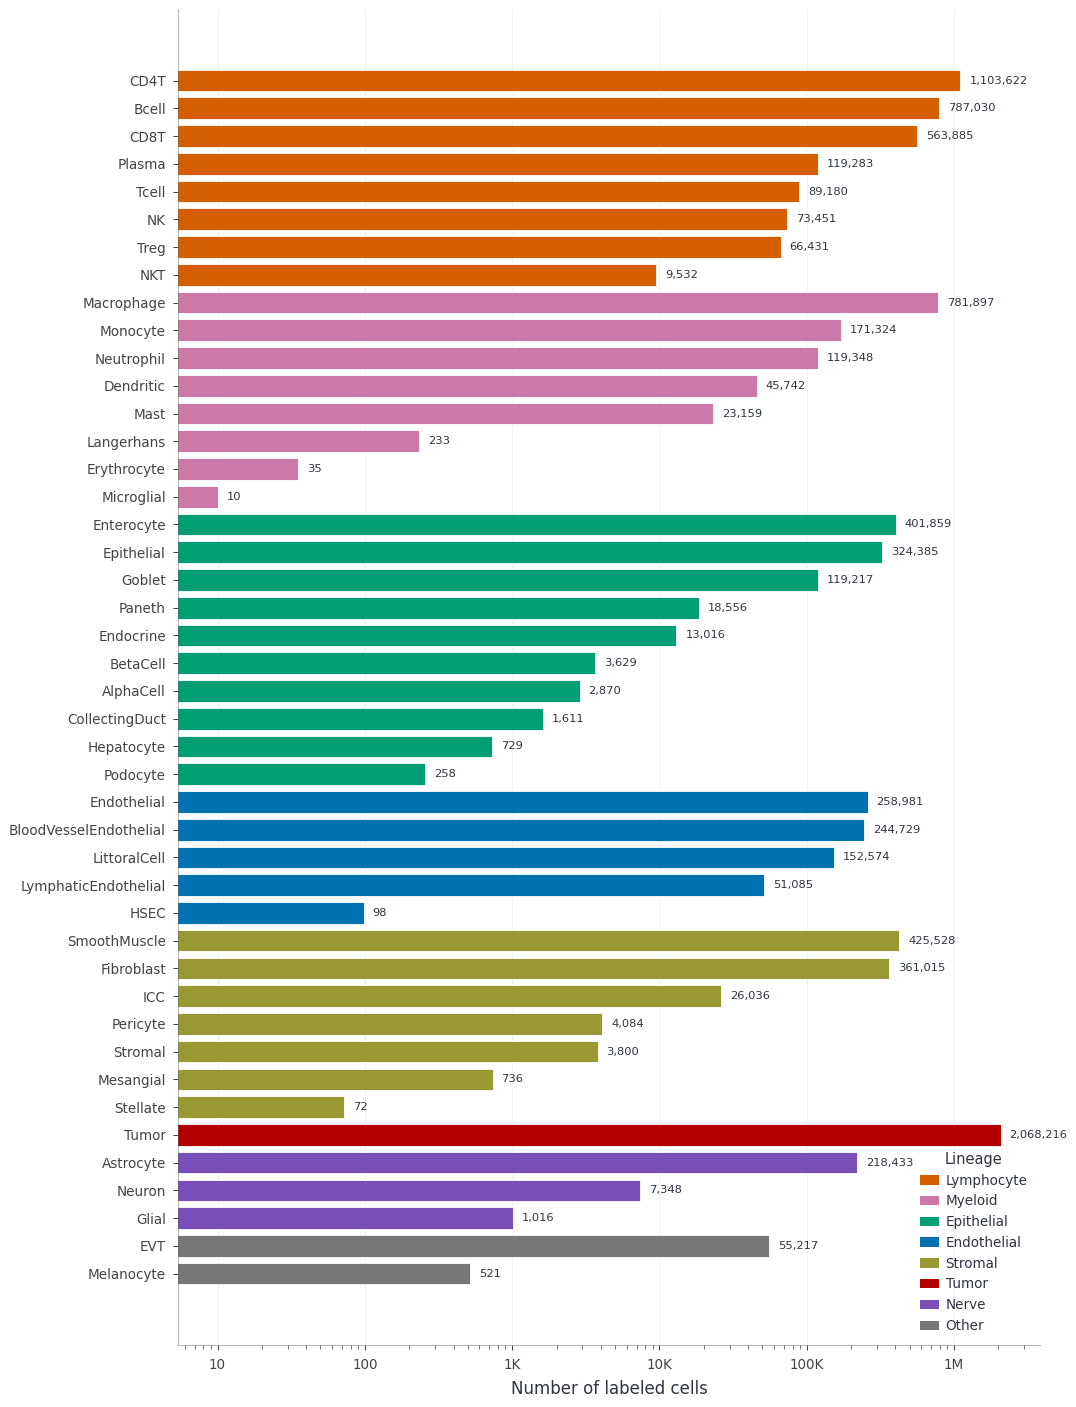

44 types, 8,719,781 cells


In [4]:
ct_total = Counter()
for r in records:
    ct_total.update(r['ct_counts'])
lineage_map = config.lineage_mapping

by_lineage = defaultdict(list)
for ctn in ct_total:
    by_lineage[_get_lineage(ctn, lineage_map)].append(ctn)
display_order = []
for lin_ in LINEAGE_ORDER:
    display_order.extend(sorted(by_lineage.get(lin_, []), key=lambda c: -ct_total[c]))
leftover = sorted((c for c in ct_total if c not in display_order),
                  key=lambda c: -ct_total[c])
display_order.extend(leftover)
sorted_cts = list(reversed(display_order))
counts = [ct_total[c] for c in sorted_cts]
cols = [LINEAGE_COLORS.get(_get_lineage(c, lineage_map), '#A0A8B4') for c in sorted_cts]

fig, ax = plt.subplots(figsize=(COL_2, min(MAX_HEIGHT, max(6.5, len(sorted_cts) * 0.22))))
bars = ax.barh(range(len(sorted_cts)), counts, color=cols, height=BAR_WIDTH,
               edgecolor='white')
ax.set_yticks(range(len(sorted_cts)))
ax.set_yticklabels(sorted_cts, fontsize=6.5)
ax.set_xlabel('Number of labeled cells')
use_log_count_axis(ax, 'x')
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() * 1.15, bar.get_y() + bar.get_height() / 2,
            f'{count:,}', va='center', fontsize=5.5, color=PAL['dark'])
_lineage_legend(lineage_map, sorted_cts, ax, loc='lower right', title='Lineage')
style_ax(ax, grid_axis='x')
fig.tight_layout()
plt.show()
print(f'{len(sorted_cts)} types, {sum(counts):,} cells')

## Composition by modality / tissue / lineage — Fig. 1b

_Caption:_ Modality, tissue, and lineage composition triptych.

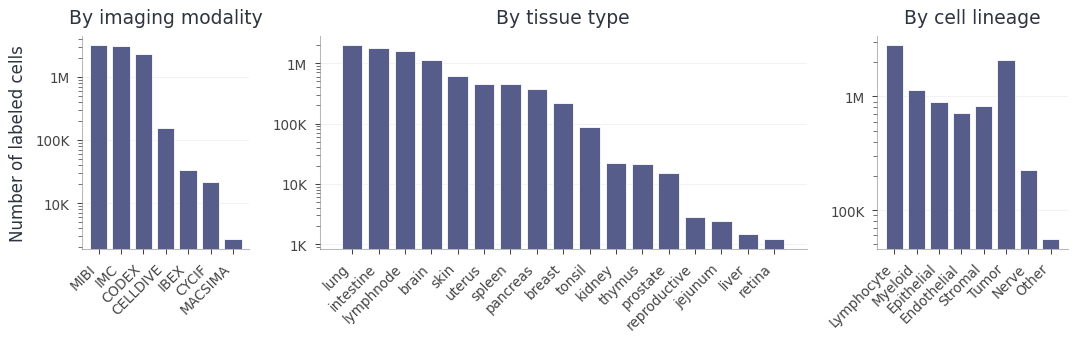

7 modalities, 17 tissues, 8 lineages


In [5]:
modality_counts, tissue_counts, lineage_counts = Counter(), Counter(), Counter()
for r in records:
    for ctn, n in r['ct_counts'].items():
        modality_counts[r['modality']] += n
        tissue_counts[r['tissue']] += n
        lineage_counts[_get_lineage(ctn, lineage_map)] += n

lineages_in = [l for l in LINEAGE_ORDER if l in lineage_counts]
n_mods = max(len(modality_counts), 1)
n_tissues = max(len(tissue_counts), 1)
n_lineages = max(len(lineages_in), 1)
fig, axes = plt.subplots(1, 3, figsize=(COL_2, 2.4),
                         gridspec_kw={'width_ratios': [n_mods, n_tissues * 1.20, n_lineages]})
for ax, (cnt, title) in zip(
        axes, [(modality_counts, 'By imaging modality'),
               (tissue_counts, 'By tissue type'),
               (None, 'By cell lineage')]):
    if title == 'By cell lineage':
        cats = lineages_in
        vals = [lineage_counts[l] for l in cats]
    else:
        cats = sorted(cnt, key=lambda x: -cnt[x])
        vals = [cnt[c] for c in cats]
    ax.bar(range(len(cats)), vals, color=PAL['theme'], width=BAR_WIDTH,
           edgecolor='white')
    ax.set_xticks(range(len(cats)))
    ax.set_xticklabels(cats, rotation=45, ha='right')
    ax.set_title(title)
    use_log_count_axis(ax, 'y')
    style_ax(ax, 'y')
axes[0].set_ylabel('Number of labeled cells')
fig.tight_layout()
plt.show()
print(f'{n_mods} modalities, {n_tissues} tissues, {n_lineages} lineages')

## Cell-type presence per dataset — Supp. Fig. 1a

_Caption:_ Cell-type presence per dataset (binary heatmap).

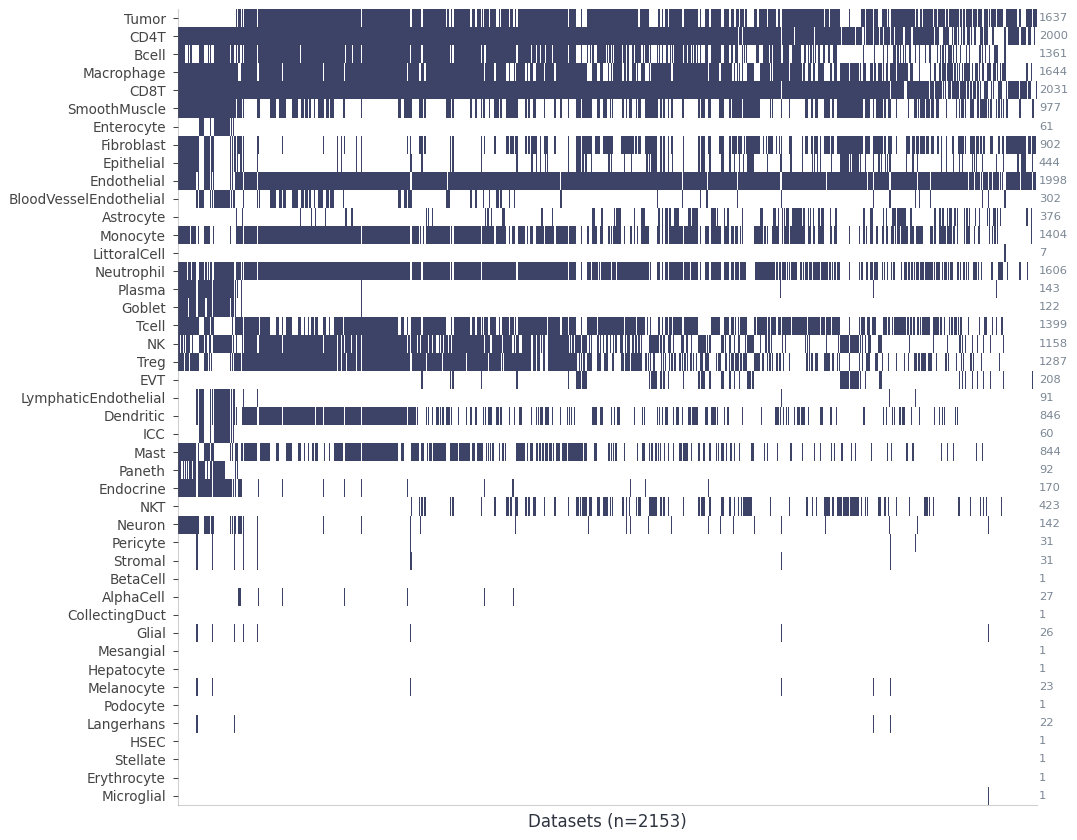

44 x 2153


In [6]:
present_cts = sorted(ct_total.keys(), key=lambda x: -ct_total[x])
matrix = np.zeros((len(present_cts), len(records)), dtype=np.float32)
for j, r in enumerate(records):
    for ctn in r['ct_counts']:
        if ctn in present_cts:
            matrix[present_cts.index(ctn), j] = 1.0
matrix = matrix[:, np.argsort(-matrix.sum(axis=0))]

fig, ax = plt.subplots(figsize=(COL_2, min(MAX_HEIGHT, max(4.0, len(present_cts) * 0.13))))
ax.imshow(matrix, aspect='auto', cmap=CMAP_BLUES, interpolation='nearest')
ax.set_yticks(range(len(present_cts)))
ax.set_yticklabels(present_cts, fontsize=6.5)
ax.set_xlabel(f'Datasets (n={len(records)})')
ax.set_xticks([])
for i, ctn in enumerate(present_cts):
    ax.text(len(records) + 3, i, str(int(matrix[i].sum())), va='center',
            fontsize=5.5, color=PAL['gray'])
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
for sp in ('left', 'bottom'):
    ax.spines[sp].set_alpha(0.3)
fig.tight_layout()
plt.show()
print(f'{len(present_cts)} x {len(records)}')

## Cell-type lineage hierarchy — Fig. 1d

_Caption:_ Cell-type lineage hierarchy used for hierarchical-collapsed eval.

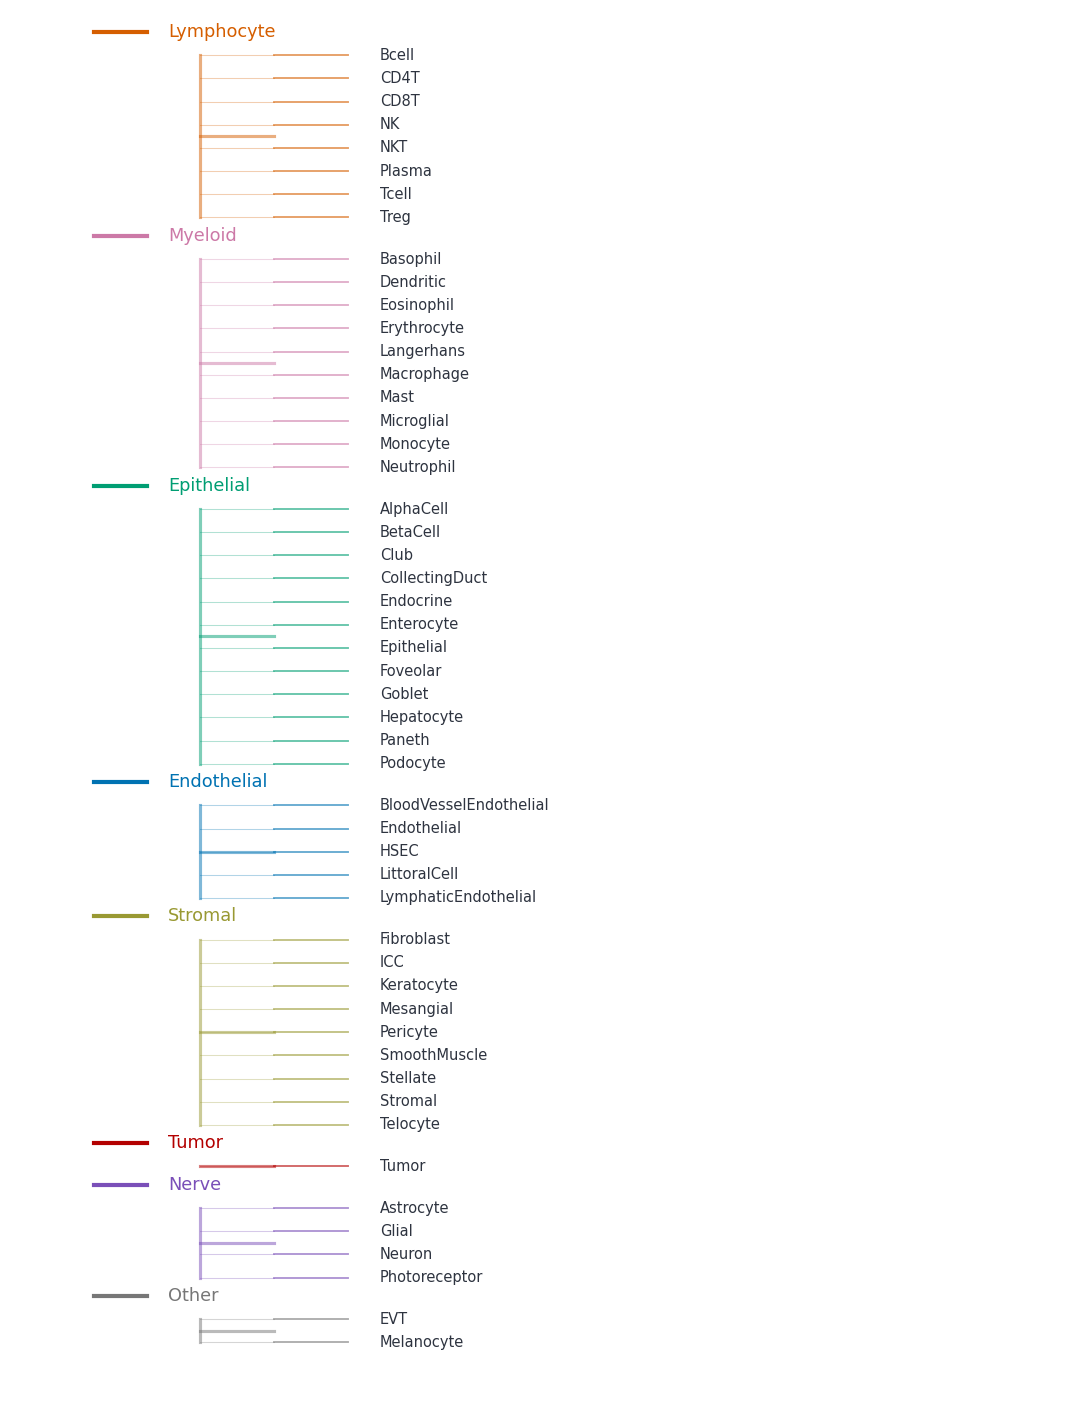

8 lineages, 51 types


In [7]:
groups = defaultdict(list)
for ctn in sorted(config.ct2idx):
    groups[_get_lineage(ctn, lineage_map)].append(ctn)
lineages = [l for l in LINEAGE_ORDER if l in groups]
total_cts = sum(len(groups[l]) for l in lineages)

fig, ax = plt.subplots(figsize=(COL_2, min(MAX_HEIGHT, max(6.0, total_cts * 0.25 + 1.0))))
ax.set_xlim(0, 10); ax.set_ylim(-1, total_cts + len(lineages)); ax.axis('off')
y = total_cts + len(lineages) - 1
for lin_ in lineages:
    color = LINEAGE_COLORS.get(lin_, '#A0A8B4')
    cts_l = groups[lin_]
    ax.text(1.5, y, lin_, fontsize=8.5, color=color, va='center')
    ax.plot([0.8, 1.3], [y, y], color=color, linewidth=2.0)
    top_y = y
    for ctn in cts_l:
        y -= 1
        ax.text(3.5, y, ctn, fontsize=7.0, va='center', color=PAL['dark'])
        ax.plot([2.5, 3.2], [y, y], color=color, linewidth=0.9, alpha=0.6)
    if cts_l:
        bottom_y = y
        mid_y = (top_y - 1 + bottom_y) / 2
        ax.plot([1.8, 1.8], [top_y - 1, bottom_y], color=color, linewidth=1.5, alpha=0.5)
        ax.plot([1.8, 2.5], [mid_y, mid_y], color=color, linewidth=1.5, alpha=0.5)
        for k in range(len(cts_l)):
            cy = top_y - 1 - k
            ax.plot([1.8, 2.5], [cy, cy], color=color, linewidth=0.5, alpha=0.3)
    y -= 0.8
fig.tight_layout()
plt.show()
print(f'{len(lineages)} lineages, {total_cts} types')

## Per-dataset cell-count distribution — Supp. Fig. 1c

_Caption:_ Per-dataset cell-count distribution.

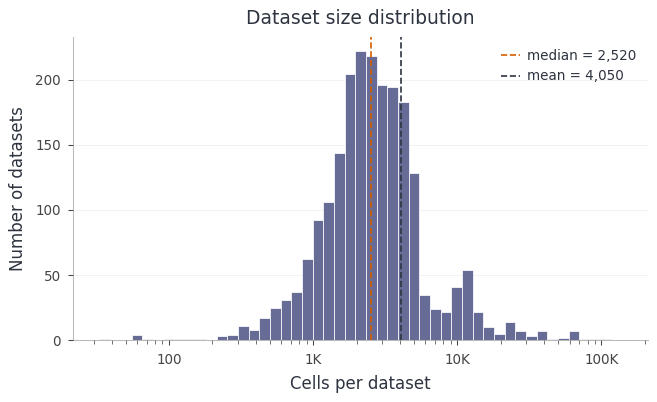

2153 datasets, median=2,520, mean=4,050


In [8]:
n_cells = np.array([r['n_cells'] for r in records])

fig, ax = plt.subplots(figsize=(COL_1_5, 2.8))
log_bins = np.logspace(np.log10(max(n_cells.min(), 1)), np.log10(n_cells.max()), 50)
ax.hist(n_cells, bins=log_bins, color=PAL['theme'], edgecolor='white', linewidth=0.4, alpha=0.9)
ax.axvline(np.median(n_cells), color=PAL['red'], linestyle='--', linewidth=0.8,
           label=f'median = {np.median(n_cells):,.0f}')
ax.axvline(np.mean(n_cells), color=PAL['dark'], linestyle='--', linewidth=0.8,
           label=f'mean = {np.mean(n_cells):,.0f}')
ax.set_xlabel('Cells per dataset'); ax.set_ylabel('Number of datasets')
ax.set_title('Dataset size distribution')
use_log_count_axis(ax, 'x'); ax.legend(loc='upper right'); style_ax(ax, 'y')
fig.tight_layout()
plt.show()
print(f'{len(records)} datasets, median={np.median(n_cells):,.0f}, mean={np.mean(n_cells):,.0f}')

## Class-imbalance curve — Supp. Fig. 1d

_Caption:_ Class imbalance curve + Lorenz ranking across the archive.

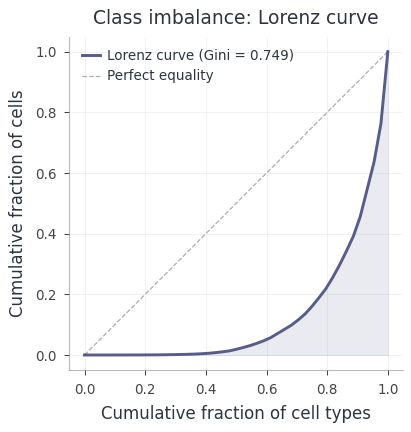

Gini=0.749


In [9]:
sorted_cts9 = sorted(ct_total.keys(), key=lambda x: ct_total[x])
counts9 = np.array([ct_total[c] for c in sorted_cts9], dtype=float)
total9 = counts9.sum()
cumulative = np.insert(np.cumsum(counts9) / total9, 0, 0)
x_frac = np.linspace(0, 1, len(cumulative))
n9 = len(counts9)
gini = (2 * np.sum(np.arange(1, n9 + 1) * counts9) - (n9 + 1) * np.sum(counts9)) / (n9 * np.sum(counts9))

fig, ax = plt.subplots(figsize=(COL_1, 3.0))
ax.fill_between(x_frac, cumulative, alpha=0.12, color=PAL['theme'])
ax.plot(x_frac, cumulative, color=PAL['theme'], linewidth=1.4,
        label=f'Lorenz curve (Gini = {gini:.3f})')
ax.plot([0, 1], [0, 1], color=PAL['dark'], linestyle='--', linewidth=0.6, alpha=0.4,
        label='Perfect equality')
ax.set_xlabel('Cumulative fraction of cell types')
ax.set_ylabel('Cumulative fraction of cells')
ax.set_title('Class imbalance: Lorenz curve')
ax.legend(loc='upper left'); ax.set_aspect('equal'); style_ax(ax, grid_axis='both')
fig.tight_layout()
plt.show()
print(f'Gini={gini:.3f}')

## Cell-type breakdown per modality — Fig. 1c

_Caption:_ Cell-type breakdown per modality.

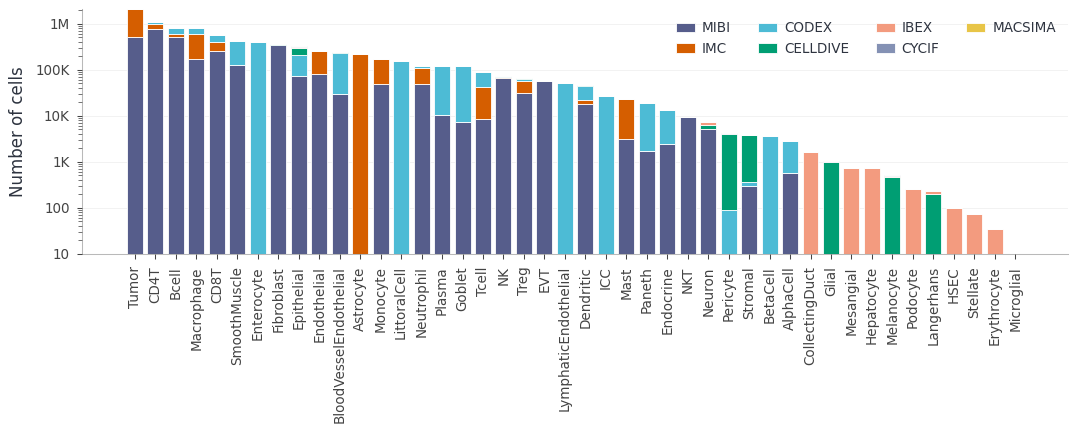

44 types x 7 modalities


In [10]:
ct_mod = defaultdict(Counter)
for r in records:
    for ctn, n in r['ct_counts'].items():
        ct_mod[ctn][r['modality']] += n
sorted_cts10 = sorted(ct_mod, key=lambda x: -sum(ct_mod[x].values()))
modalities10 = sorted(set(m for c in ct_mod.values() for m in c),
                      key=lambda m: -sum(ct_mod[c][m] for c in sorted_cts10))
x = np.arange(len(sorted_cts10))
fig, ax = plt.subplots(figsize=(COL_2, 3.0))
bottom = np.zeros(len(sorted_cts10))
for k, mod_ in enumerate(modalities10):
    vals = np.array([ct_mod[c][mod_] for c in sorted_cts10], dtype=float)
    ax.bar(x, vals, bottom=bottom, label=mod_,
           color=STACKED_COLORS[k % len(STACKED_COLORS)], width=BAR_WIDTH, edgecolor='white')
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels(sorted_cts10, rotation=90)
ax.set_ylabel('Number of cells')
ax.legend(ncol=min(len(modalities10), 4), loc='upper right')
use_log_count_axis(ax, 'y'); style_ax(ax, 'y')
fig.tight_layout()
plt.show()
print(f'{len(sorted_cts10)} types x {len(modalities10)} modalities')

## Channel co-occurrence (Jaccard) — Supp. Fig. 1b

_Caption:_ Channel co-occurrence (Jaccard similarity across datasets).

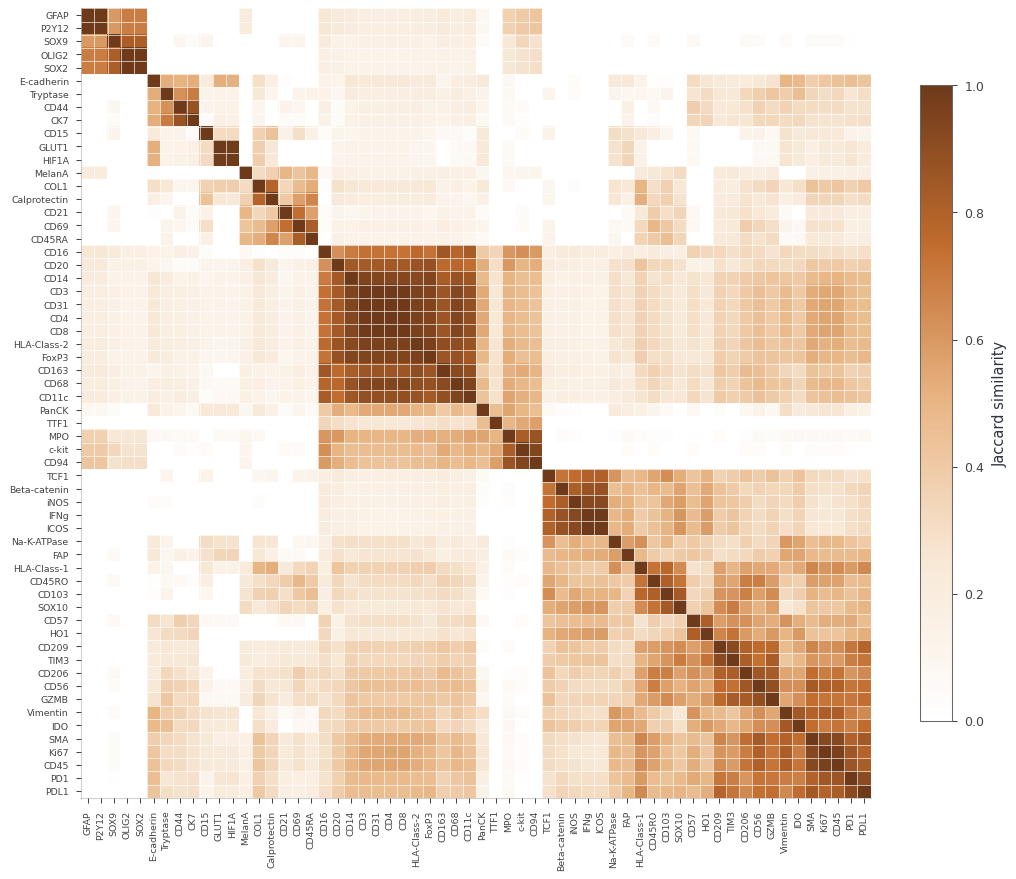

60 x 60 Jaccard matrix


In [11]:
top_n11 = 60
channel_datasets = defaultdict(set)
for i, r in enumerate(records):
    for ch in r['channels']:
        channel_datasets[ch].add(i)
top_channels = sorted(channel_datasets, key=lambda c: -len(channel_datasets[c]))[:top_n11]
n11 = len(top_channels)
sim = np.zeros((n11, n11))
for i in range(n11):
    for j in range(i, n11):
        a, b = channel_datasets[top_channels[i]], channel_datasets[top_channels[j]]
        jac = len(a & b) / max(len(a | b), 1)
        sim[i, j] = sim[j, i] = jac
dist = 1 - sim
np.fill_diagonal(dist, 0)
order = leaves_list(linkage(squareform(dist, checks=False), method='average'))
sim_sorted = sim[order][:, order]
labels_sorted = [top_channels[i] for i in order]

fig, ax = plt.subplots(figsize=(COL_2, COL_2))
im = ax.imshow(sim_sorted, cmap=CMAP_WARM, interpolation='nearest', vmin=0, vmax=1)
ax.set_xticks(range(n11)); ax.set_xticklabels(labels_sorted, rotation=90, fontsize=4.5)
ax.set_yticks(range(n11)); ax.set_yticklabels(labels_sorted, fontsize=4.5)
cb = fig.colorbar(im, ax=ax, shrink=0.6)
cb.set_label('Jaccard similarity', fontsize=7); cb.ax.tick_params(labelsize=6)
ax.set_xticks(np.arange(-0.5, n11, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n11, 1), minor=True)
ax.grid(which='minor', color='white', linewidth=0.3)
ax.tick_params(which='minor', size=0)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
for sp in ('left', 'bottom'):
    ax.spines[sp].set_alpha(0.3)
fig.tight_layout()
plt.show()
print(f'{n11} x {n11} Jaccard matrix')

## Panel-size distribution — Supp. Fig. 1e

_Caption:_ Distribution of the number of standardized markers (channels) per FOV.

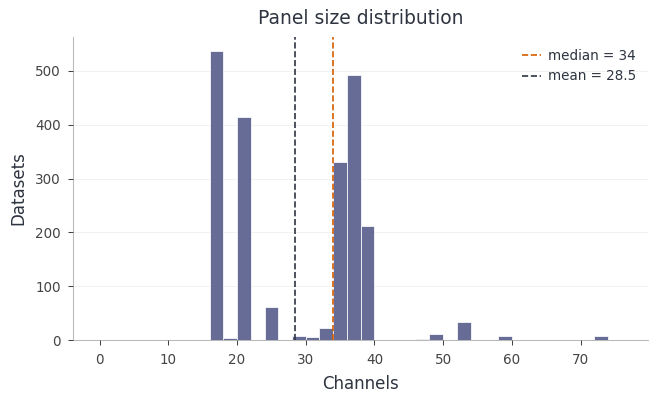

304 unique markers, median panel=34 channels


In [12]:
n_channels = [r['n_channels'] for r in records]
n_unique = len(set(ch for r in records for ch in r['channels']))

fig, ax = plt.subplots(figsize=(COL_1_5, 2.8))
ax.hist(n_channels, bins=range(0, max(n_channels) + 5, 2), color=PAL['theme'],
        edgecolor='white', linewidth=0.4, alpha=0.9)
ax.axvline(np.median(n_channels), color=PAL['red'], linestyle='--', linewidth=0.8,
           label=f'median = {np.median(n_channels):.0f}')
ax.axvline(np.mean(n_channels), color=PAL['dark'], linestyle='--', linewidth=0.8,
           label=f'mean = {np.mean(n_channels):.1f}')
ax.set_xlabel('Channels'); ax.set_ylabel('Datasets')
ax.set_title('Panel size distribution'); ax.legend(loc='upper right'); style_ax(ax, 'y')
fig.tight_layout()
plt.show()
print(f'{n_unique} unique markers, median panel={np.median(n_channels):.0f} channels')

### Cached per-cell intensity table

The marker-discriminability AUC panel reads the pre-computed long-form per-cell
mean-intensity table (`figures_data/channel_intensity_stats.npz`; columns
`marker`, `intensity`, `cell_type`) so it skips a full archive raw-array
rescan.

In [13]:
with np.load(paths.need(paths.FIGURES_DATA / 'channel_intensity_stats.npz'),
             allow_pickle=True) as d:
    intensity_stats = {'marker': d['marker'], 'intensity': d['intensity'],
                       'cell_type': d['cell_type']}
print(f"intensity table: {len(intensity_stats['marker']):,} rows, "
      f"{(intensity_stats['cell_type'] != '').sum():,} with cell-type labels")

intensity table: 594,000 rows, 280,436 with cell-type labels


## Single-channel marker discriminability (mutual information) — Supp. Fig. 3

_Caption:_ Per-cell mutual information (in bits) between each marker's intensity
and the one-vs-rest cell-type indicator. Intensities are quantile-binned (16
bins shared across cell types per row); each entry is the plug-in MI
$I(X; Y)$ between the binned intensity $X$ and the binary membership label
$Y = \mathbb{1}[\text{cell} = \text{ct}]$ (0 bits = intensity uninformative
about membership). Rows ranked by max MI across cell types, columns grouped by
lineage; gray cells fall below the minimum-support floor.

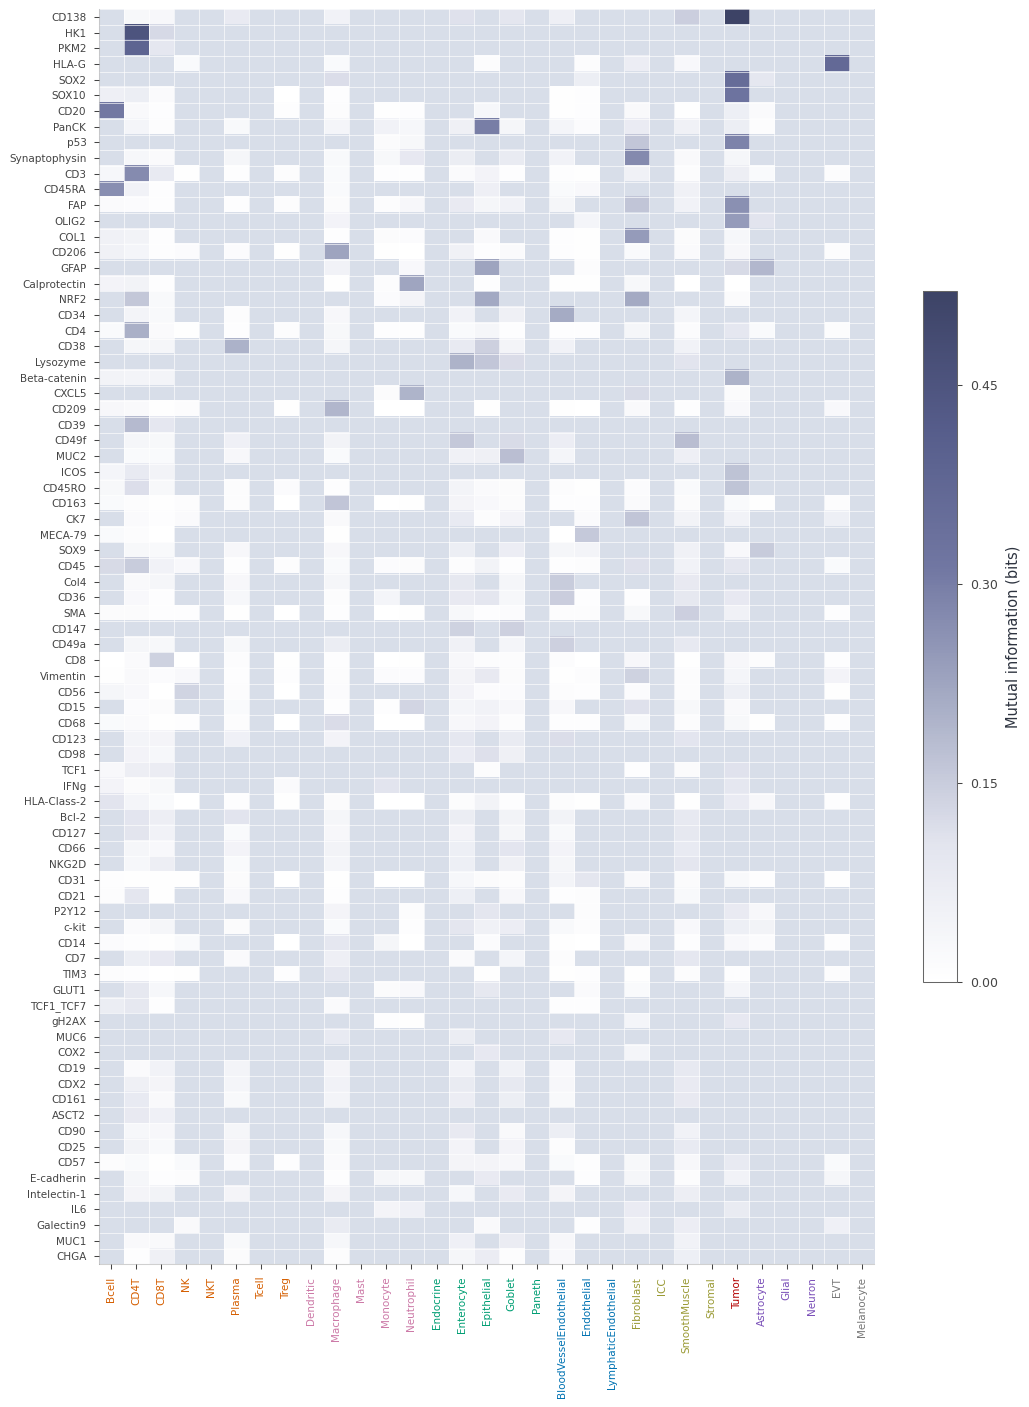

80 markers x 31 cell types, 769 valid pairs (gray = below support floor)


In [14]:
# Per-cell mutual information (bits) between each marker's intensity and the
# one-vs-rest cell-type indicator. For each marker (row) the intensities are
# quantile-binned into 16 bins shared across cell types; each entry is the
# plug-in MI I(X; Y) between the binned intensity X and Y = 1[cell == ct], in
# bits (0 = intensity uninformative about membership). Rows ranked by max MI,
# columns grouped by lineage; gray = below the support floor.
top_n17, min_pos, min_neg, n_bins = 80, 30, 200, 16
mk17 = intensity_stats['marker']; it17 = intensity_stats['intensity']
ct17 = intensity_stats['cell_type']
labelled = (ct17 != '') & np.isin(ct17, list(config.ct2idx))
mk17, it17, ct17 = mk17[labelled], it17[labelled], ct17[labelled]


def _mi_bits(xbin, y, n_levels):
    """Plug-in mutual information I(X; Y) in bits (X binned, Y binary)."""
    joint = np.zeros((n_levels, 2), dtype=np.float64)
    np.add.at(joint, (xbin, y), 1.0)
    pxy = joint / joint.sum()
    px = pxy.sum(axis=1, keepdims=True)
    py = pxy.sum(axis=0, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        terms = pxy * (np.log2(pxy) - np.log2(px) - np.log2(py))
    return float(terms[pxy > 0].sum())


if not labelled.any():
    print('  [17] no labelled per-cell intensity rows — skipping')
else:
    unique_markers = sorted(set(map(str, mk17)))
    unique_cts = sorted(set(map(str, ct17)),
                        key=lambda c: (LINEAGE_ORDER.index(lineage_map.get(c, 'Other'))
                                       if lineage_map.get(c, 'Other') in LINEAGE_ORDER else 99, c))
    mi_bits = np.full((len(unique_markers), len(unique_cts)), np.nan, dtype=np.float32)
    for row, m in enumerate(unique_markers):
        sel = mk17 == m
        if not sel.any():
            continue
        x_, c_ = it17[sel], ct17[sel]
        edges = np.unique(np.quantile(x_, np.linspace(0.0, 1.0, n_bins + 1)))
        if edges.size < 2:
            continue
        xbin = np.clip(np.digitize(x_, edges[1:-1]), 0, edges.size - 2)
        for cj, ctn in enumerate(unique_cts):
            pos = c_ == ctn
            n_p = int(pos.sum()); n_n = x_.size - n_p
            if n_p < min_pos or n_n < min_neg:
                continue
            mi_bits[row, cj] = _mi_bits(xbin, pos.astype(np.int64), edges.size - 1)

    row_max = np.nanmax(mi_bits, axis=1)
    valid_rows = np.isfinite(row_max)
    if not valid_rows.any():
        print(f'  [17] all pairs below support floor (min_pos={min_pos}, '
              f'min_neg={min_neg}) — skipping')
    else:
        order17 = np.argsort(-np.where(valid_rows, row_max, -np.inf))[:min(top_n17, valid_rows.sum())]
        markers_sub = [unique_markers[i] for i in order17]
        mi_sub = mi_bits[order17]
        vmax = float(np.nanmax(mi_sub)) or 1.0
        masked = np.ma.masked_invalid(mi_sub)
        cmap = CMAP_BLUES.copy(); cmap.set_bad(color=PAL['light_gray'])
        fig, ax = plt.subplots(figsize=(COL_2, min(MAX_HEIGHT, max(5.0, len(markers_sub) * 0.13))))
        im = ax.imshow(masked, aspect='auto', cmap=cmap, vmin=0.0, vmax=vmax, interpolation='nearest')
        ax.set_yticks(range(len(markers_sub))); ax.set_yticklabels(markers_sub, fontsize=5.0)
        ax.set_xticks(range(len(unique_cts)))
        ax.set_xticklabels(unique_cts, rotation=90, fontsize=5.0)
        for i, ctn in enumerate(unique_cts):
            ax.get_xticklabels()[i].set_color(
                LINEAGE_COLORS.get(lineage_map.get(ctn, 'Other'), PAL['dark']))
        cb = fig.colorbar(im, ax=ax, shrink=0.55)
        cb.set_label('Mutual information (bits)', fontsize=7); cb.ax.tick_params(labelsize=6)
        cb.locator = mticker.MaxNLocator(5); cb.update_ticks()
        ax.set_xticks(np.arange(-0.5, len(unique_cts), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(markers_sub), 1), minor=True)
        ax.grid(which='minor', color='white', linewidth=0.3); ax.tick_params(which='minor', size=0)
        for sp in ('top', 'right'):
            ax.spines[sp].set_visible(False)
        for sp in ('left', 'bottom'):
            ax.spines[sp].set_alpha(0.3)
        fig.tight_layout()
        plt.show()
        print(f'{len(markers_sub)} markers x {len(unique_cts)} cell types, '
              f'{int(np.isfinite(mi_sub).sum()):,} valid pairs '
              f'(gray = below support floor)')